In [1]:
#general imports
# import h5py
# import meteor
# import reciprocalspaceship as rs
import numpy as np
from scipy.ndimage import gaussian_filter
# my imports
from occupancy import *
from plotting3d import *
from generate_objects import *

In [2]:
%load_ext autoreload 
%autoreload 2

In [3]:
# "Latex style"
import matplotlib
matplotlib.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,
}
)

# Setup

In [4]:
%matplotlib inline
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [5]:
alpha_xtrs = np.linspace(1e-2,1, 5)
alpha_xtrs = np.linspace(1e-2,1, 150)
alpha_xtrs = np.linspace(1e-2,1, 50)

alpha_0 = 0.27
alpha = 0.27
noise_level = 0.0
offset = True
scaleit = True
from generate_objects import generate_obj_cistrans_v2
obj0, obj1, f_dark, f_light, delta_fa_abs, imagetype =  generate_obj_cistrans_v2(alpha, noise_level, offset, scaleit)



if "2d" in imagetype:
    strict = 0.005
    lax = 0.001
    mask_thresh = 0.0003
else:
    strict = 0.05 * alpha/alpha_0
    lax = 0.015 * alpha/alpha_0
    mask_thresh = 0.03 * alpha/alpha_0


config = Config(imagetype, alpha)
print(imagetype)

delta_obj = obj1-obj0
f_xtrs = make_f_xtr(alpha_xtrs, f_dark, f_light, np.angle(f_dark),  version=1, noise_level = 0)
comb = np.stack((obj0,obj1))
np.save("objs.npy",comb)

Running scaleit, see tmp/launch_scaleit.sh
ct_occ_27_noise_0


(-0.5, 143.5, 119.5, -0.5)

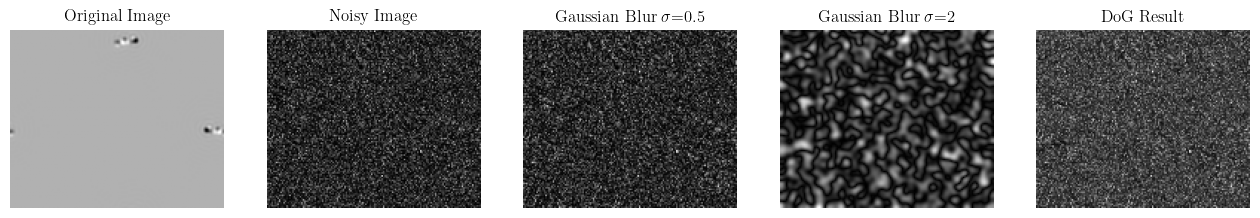

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_float
from scipy.ndimage import gaussian_filter
obj0, obj1 = np.load("objs.npy")
# Load the camera image
idx = 0

image = obj0[idx]-obj1[idx]+np.random.normal(0, 0.05, size=obj0[0].shape)
sigma1 = 0.5
sigma2 = 2
blur1 = np.abs(gaussian_filter(image, sigma=sigma1))
blur2 = np.abs(gaussian_filter(image, sigma=sigma2))

# Difference of Gaussians
dog = blur1 - blur2
fig, axes = plt.subplots(1, 5, figsize=(16, 5))

axes[0].imshow(obj0[idx]-obj1[idx], cmap="gray")
axes[0].set_title("Original Image")

axes[0].axis('off')
axes[1].imshow(np.abs(image), cmap='gray')
axes[1].set_title("Noisy Image")
axes[1].axis('off')

axes[2].imshow(blur1, cmap='gray')
axes[2].set_title(f"Gaussian Blur $\\sigma$={sigma1}")
axes[2].axis('off')

axes[3].imshow(blur2, cmap='gray')
axes[3].set_title(f"Gaussian Blur $\\sigma$={sigma2}")
axes[3].axis('off')

axes[4].imshow(dog, cmap='gray')
axes[4].set_title("DoG Result")
axes[4].axis('off')


In [ ]:
plt.imshow(